# Notebook 2 — Orientation tuning in a control vs. test condition

**Summer course: data-analysis pitfalls**

An orientation-tuning experiment was run in two conditions. For a population of
V1 neurons we have spike counts to drifting gratings at 12 directions (spaced
30 degrees, 10 repeats each, counted in a brief window), in a **control**
condition and a **test** condition (some experimental manipulation). A colleague
ran the standard tuning analysis below and concluded:

> ### The claim
> *"These neurons are orientation tuned, and the test manipulation reduces their
> responsiveness: at each neuron's **preferred orientation**, the evoked firing
> rate is markedly higher in the control condition than in the test condition
> (p < 1e-5)."*

Run the analysis — you'll reproduce exactly that.

**The key conclusion (the reduction) is not supported by this analysis.** Your
job is to work out *why*. Sit with it before looking anything up. Worth asking:
which parts of this figure are real properties of the neurons, and which are
properties of *how the figure was made*? If you get stuck, `hints.md` has
guiding questions and `notebook2_solution.ipynb` has the answer.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import wilcoxon

# --- Plotting style ---
plt.rcParams['font.family']       = 'Arial'
plt.rcParams['font.sans-serif']   = ['Arial', 'DejaVu Sans']
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['pdf.fonttype']      = 42
plt.rcParams['ps.fonttype']       = 42

CONTROL, TEST = 0, 1
COND_COLOR = {'control': 'k', 'test': '0.6'}
COND_LABEL = {'control': 'Control', 'test': 'Test'}
rng = np.random.default_rng(0)

def load(fname):
    d = np.load(fname, allow_pickle=True)
    return (d['counts'], float(d['duration']), d['orientations'],
            [str(x) for x in d['condition_names']])

def preferred_ori(rate_by_ori):
    # argmax over orientation, breaking ties AT RANDOM. Counts are small
    # integers so exact ties are common; np.argmax's first-index rule would
    # bias the "preferred" orientation toward the first-listed direction.
    return (rate_by_ori + rng.uniform(0, 1e-9, rate_by_ori.shape)).argmax(1)

def roll_to_center(rate_by_ori, pref_idx):
    n_ori = rate_by_ori.shape[1]; center = n_ori // 2
    return np.array([np.roll(rate_by_ori[i], center - pref_idx[i])
                     for i in range(rate_by_ori.shape[0])])


In [2]:
counts, duration, orientations, condition_names = load('data/tuned.npz')
n_neurons, n_ori, n_cond, n_trials = counts.shape
print(f'{n_neurons} neurons x {n_ori} directions x {n_cond} conditions '
      f'x {n_trials} trials')


200 neurons x 12 directions x 2 conditions x 10 trials


## Step 1 — Mean firing rate, then align to each neuron's preferred direction

Average spike counts over trials (spikes/s), define each neuron's preferred
direction from the control condition, and align both conditions to it.


In [3]:
rate = counts / duration                  # spike counts -> firing rate (spikes/s)
mean_rate = rate.mean(axis=3)             # average over trials -> (neuron, ori, condition)

# Each neuron's preferred direction = the direction with the largest CONTROL
# response, then circularly shift every neuron so its preferred direction sits
# at the center column (so the curves can be averaged across neurons).
pref_idx = preferred_ori(mean_rate[:, :, CONTROL])
aligned_control = roll_to_center(mean_rate[:, :, CONTROL], pref_idx)
aligned_test    = roll_to_center(mean_rate[:, :, TEST],    pref_idx)

center = n_ori // 2
# x-axis in degrees relative to the preferred direction (0 = preferred)
rel_ori = (np.arange(n_ori) - center) * (orientations[1] - orientations[0])


## Step 2 — Mean tuning curve, control vs. test


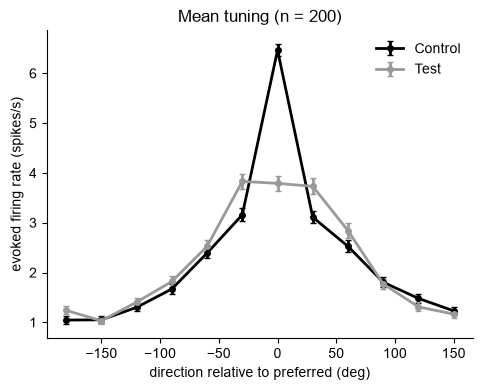

Firing rate at preferred direction:
  Control : 6.46 +/- 0.12 sp/s
  Test    : 3.79 +/- 0.15 sp/s
  Wilcoxon signed-rank test: p = 9.86e-26


In [4]:
fig, ax = plt.subplots(figsize=(5.5, 4))
for cond, curves in [('control', aligned_control), ('test', aligned_test)]:
    m = curves.mean(0); sem = curves.std(0) / np.sqrt(n_neurons)
    ax.errorbar(rel_ori, m, yerr=sem, color=COND_COLOR[cond], lw=2,
                marker='o', ms=4, capsize=2, label=COND_LABEL[cond])
ax.set_xlabel('direction relative to preferred (deg)')
ax.set_ylabel('evoked firing rate (spikes/s)')
ax.set_title('Mean tuning (n = %d)' % n_neurons)
ax.legend(frameon=False)
plt.show()

# Compare the two conditions at the preferred direction (the center column),
# neuron by neuron, with a paired non-parametric test.
p_ctrl = aligned_control[:, center]; p_test = aligned_test[:, center]
w = wilcoxon(p_ctrl, p_test)
print(f'Firing rate at preferred direction:')
print(f'  Control : {p_ctrl.mean():.2f} +/- {p_ctrl.std()/np.sqrt(n_neurons):.2f} sp/s')
print(f'  Test    : {p_test.mean():.2f} +/- {p_test.std()/np.sqrt(n_neurons):.2f} sp/s')
print(f'  Wilcoxon signed-rank test: p = {w.pvalue:.2e}')


Sharp tuning, and a large, highly significant drop at the preferred direction in
the test condition. The conclusion follows directly from this figure.
